In [5]:

import sys
sys.path.append("C:\scripts\Imaging analysis")
sys.path.append("C:\scripts\Imaging analysis\src")
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from alm_2p import session
from matplotlib.pyplot import figure
from numpy import concatenate as cat
from sklearn.preprocessing import normalize
import quality
from scipy import stats
from scipy.stats import zscore
from activityMode import Mode
cat = np.concatenate

plt.rcParams['pdf.fonttype'] = '42' 

In [1]:
import scipy
def dodownsample(a):
    """
    Downsample for CW 44, 46 to fit with prev data

    Parameters
    ----------
    a : TYPE
        DESCRIPTION.

    Returns
    -------
    a : TYPE
        DESCRIPTION.

    """
    b=np.zeros(61)
    
    a=np.array(a)
    
    if len(a.shape) == 1:
        x = np.arange(-6.97,6,1/30)[:a.shape[0]*2]
        nums = np.interp(x, np.arange(-6.97,6,1/15)[:a.shape[0]], a)
        b = np.vstack((b, scipy.signal.decimate(nums, 5)))
        return b[1:]

    for i in range(len(a)):
        x = np.arange(-6.97,6,1/30)[:a.shape[1]*2]
        nums = np.interp(x, np.arange(-6.97,6,1/15)[:a.shape[1]], a[i])
        b = np.vstack((b, scipy.signal.decimate(nums, 5)))
    
    return b[1:]

In [26]:
all_matched_paths_permouse = [
    
            [r'F:\data\BAYLORCW032\python\2023_10_05',
              r'F:\data\BAYLORCW032\python\2023_10_19',
              r'F:\data\BAYLORCW032\python\2023_10_24',
          ],
         
            # [ r'F:\data\BAYLORCW034\python\2023_10_12',
            #    r'F:\data\BAYLORCW034\python\2023_10_22',
            #    r'F:\data\BAYLORCW034\python\2023_10_27',
            #    r'F:\data\BAYLORCW034\python\cellreg\layer{}\1012_1022_1027pairs_proc.npy'],
         
            [r'F:\data\BAYLORCW036\python\2023_10_09',
            r'F:\data\BAYLORCW036\python\2023_10_19',
            r'F:\data\BAYLORCW036\python\2023_10_30',
           ],
         
         [r'F:\data\BAYLORCW037\python\2023_11_21',
            r'F:\data\BAYLORCW037\python\2023_12_08',
            r'F:\data\BAYLORCW037\python\2023_12_15',],
         
         [r'F:\data\BAYLORCW035\python\2023_10_26',
            r'F:\data\BAYLORCW035\python\2023_12_07',
            r'F:\data\BAYLORCW035\python\2023_12_15',],
         
         [r'H:\data\BAYLORCW044\python\2024_05_22',
          r'H:\data\BAYLORCW044\python\2024_06_06',
        r'H:\data\BAYLORCW044\python\2024_06_19'],

         
        #     [r'H:\data\BAYLORCW044\python\2024_05_23',
        #      r'H:\data\BAYLORCW044\python\2024_06_04',
        # r'H:\data\BAYLORCW044\python\2024_06_18'],

            # [r'H:\data\BAYLORCW046\python\2024_05_29',
            #  r'H:\data\BAYLORCW046\python\2024_06_07',
            #  r'H:\data\BAYLORCW046\python\2024_06_28'],


            # [r'H:\data\BAYLORCW046\python\2024_05_30',
            #  r'H:\data\BAYLORCW046\python\2024_06_10',
            #  r'H:\data\BAYLORCW046\python\2024_06_27'],

            [r'H:\data\BAYLORCW046\python\2024_05_31',
             r'H:\data\BAYLORCW046\python\2024_06_11',
             r'H:\data\BAYLORCW046\python\2024_06_26'
             ]
         
        ]

# Fig 2 plots

Behavior plot

In [27]:
beh_acc = []
beh_acc_stim = []

for paths in all_matched_paths_permouse:

    naivepath, learningpath, expertpath = paths
    s1 = session.Session(naivepath)
    _, _, ctlperf_nai = s1.performance_in_trials(s1.i_good_non_stim_trials)
    _, _, ctlperf_nai_stim = s1.performance_in_trials(s1.i_good_stim_trials)
    s1 = session.Session(learningpath)
    _, _, ctlperf_learn = s1.performance_in_trials(s1.i_good_non_stim_trials)
    _, _, ctlperf_learn_stim = s1.performance_in_trials(s1.i_good_stim_trials)
    s1 = session.Session(expertpath)
    _, _, ctlperf_exp = s1.performance_in_trials(s1.i_good_non_stim_trials)
    _, _, ctlperf_exp_stim = s1.performance_in_trials(s1.i_good_stim_trials)

    beh_acc.append([ctlperf_nai, ctlperf_learn, ctlperf_exp])
    beh_acc_stim.append([ctlperf_nai_stim, ctlperf_learn_stim, ctlperf_exp_stim])

Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-1.8049724
-1.8049724
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
5.565901
5.565901
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
0.09465302
0.09465302
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
1.1002567
1.1002567
Using Pearsons corr to filter neurons.

In [ ]:
beh_acc_trace = []

for paths in all_matched_paths_permouse:

    naivepath, learningpath, expertpath = paths
    s1 = session.Session(naivepath)
    _, _, ctlperf_nai = s1.performance_in_trials(s1.i_good_non_stim_trials)
    s1 = session.Session(learningpath)
    _, _, ctlperf_learn = s1.performance_in_trials(s1.i_good_non_stim_trials)
    s1 = session.Session(expertpath)
    _, _, ctlperf_exp = s1.performance_in_trials(s1.i_good_non_stim_trials)

    beh_acc.append([ctlperf_nai, ctlperf_learn, ctlperf_exp])
    beh_acc_stim.append([ctlperf_nai_stim, ctlperf_learn_stim, ctlperf_exp_stim])

array([[0.58898305, 0.79310345, 0.85046729],
       [0.41935484, 0.62202381, 0.79256966],
       [0.46127946, 0.60833333, 0.76557864],
       [0.63942308, 0.64876033, 0.74021352],
       [0.40390879, 0.75250836, 0.92592593],
       [0.48318043, 0.78816199, 0.96842105],
       [0.56547619, 0.58293839, 0.76497696],
       [0.45918367, 0.77338129, 0.84453782],
       [0.46987952, 0.64705882, 0.80357143]])

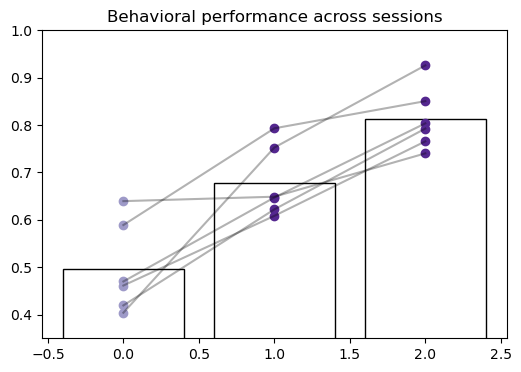

In [30]:
f=plt.figure(figsize=(6,4))

beh_acc = np.array(beh_acc)

plt.bar(range(3), np.mean(beh_acc, axis=0), fill=False, edgecolor='black')#, barwidth=0.5)
plt.scatter(np.zeros(len(beh_acc[:,0])), beh_acc[:,0], color='#9e9ac8')
plt.scatter(np.ones(len(beh_acc[:,1])), beh_acc[:,1], color='#54278f')
plt.scatter(np.ones(len(beh_acc[:,2]))*2, beh_acc[:,2], color='#54278f')

for i in range(beh_acc.shape[0]):
    plt.plot([0,1,2], beh_acc[i], color='black', alpha=0.3)

# plt.plot([0,1,2],  np.mean(beh_acc, axis=0), color='black', linestyle='--', linewidth=1)
plt.ylim(0.35,1)
plt.title('Behavioral performance across sessions')
plt.savefig(r'P:\paperfigures\fig2\beh_acc_across_sessions.pdf')
plt.show()

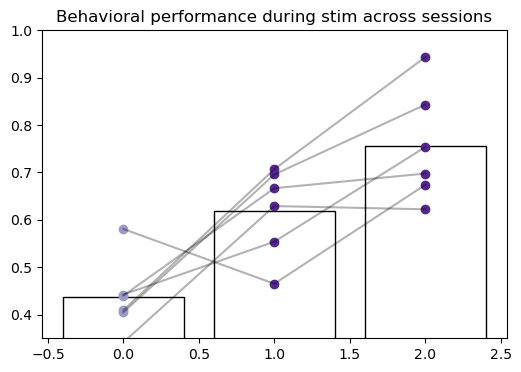

In [29]:
f=plt.figure(figsize=(6,4))

beh_acc_stim = np.array(beh_acc_stim)

plt.bar(range(3), np.mean(beh_acc_stim, axis=0), fill=False, edgecolor='black')#, barwidth=0.5)
plt.scatter(np.zeros(len(beh_acc_stim[:,0])), beh_acc_stim[:,0], color='#9e9ac8')
plt.scatter(np.ones(len(beh_acc_stim[:,1])), beh_acc_stim[:,1], color='#54278f')
plt.scatter(np.ones(len(beh_acc_stim[:,2]))*2, beh_acc_stim[:,2], color='#54278f')

for i in range(beh_acc_stim.shape[0]):
    plt.plot([0,1,2], beh_acc_stim[i], color='black', alpha=0.3)

# plt.plot([0,1,2],  np.mean(beh_acc, axis=0), color='black', linestyle='--', linewidth=1)
plt.ylim(0.35,1)
plt.title('Behavioral performance during stim across sessions')
plt.show()

Plot behavior during imaging sessions as a trace:

In [57]:
all_matched_paths_permouse = [
    
            [r'F:\data\BAYLORCW032\python\2023_10_05',
              r'F:\data\BAYLORCW032\python\2023_10_19',
              r'F:\data\BAYLORCW032\python\2023_10_24',
          ],
         
            [ r'F:\data\BAYLORCW034\python\2023_10_12',
               r'F:\data\BAYLORCW034\python\2023_10_22',
               r'F:\data\BAYLORCW034\python\2023_10_27',
            #    r'F:\data\BAYLORCW034\python\cellreg\layer{}\1012_1022_1027pairs_proc.npy'
               ],
         
            [r'F:\data\BAYLORCW036\python\2023_10_09',
            r'F:\data\BAYLORCW036\python\2023_10_19',
            r'F:\data\BAYLORCW036\python\2023_10_30',
           ],
         
         [r'F:\data\BAYLORCW037\python\2023_11_21',
            r'F:\data\BAYLORCW037\python\2023_12_08',
            r'F:\data\BAYLORCW037\python\2023_12_15',],
         
         [r'F:\data\BAYLORCW035\python\2023_10_26',
            r'F:\data\BAYLORCW035\python\2023_12_07',
            r'F:\data\BAYLORCW035\python\2023_12_15',],
         
         [r'H:\data\BAYLORCW044\python\2024_05_22',
          r'H:\data\BAYLORCW044\python\2024_06_06',
        r'H:\data\BAYLORCW044\python\2024_06_19'],

         
        #     [r'H:\data\BAYLORCW044\python\2024_05_23',
        #      r'H:\data\BAYLORCW044\python\2024_06_04',
        # r'H:\data\BAYLORCW044\python\2024_06_18'],

            # [r'H:\data\BAYLORCW046\python\2024_05_29',
            #  r'H:\data\BAYLORCW046\python\2024_06_07',
            #  r'H:\data\BAYLORCW046\python\2024_06_28'],


            # [r'H:\data\BAYLORCW046\python\2024_05_30',
            #  r'H:\data\BAYLORCW046\python\2024_06_10',
            #  r'H:\data\BAYLORCW046\python\2024_06_27'],

            [r'H:\data\BAYLORCW046\python\2024_05_29',
             r'H:\data\BAYLORCW046\python\2024_06_11',
             r'H:\data\BAYLORCW046\python\2024_06_26'
             ]
         
        ]

window=50

beh_arr_naive, beh_arr_learning, beh_arr_expert = [],[],[]

for paths in all_matched_paths_permouse:

    naivepath, learningpath, expertpath = paths
    s1 = session.Session(naivepath)
    correct = s1.L_correct + s1.R_correct
    correct = np.convolve(correct, np.ones(window*2)/(window*2), mode = 'same')
    beh_arr_naive.append(correct[window:-window])    
    s1 = session.Session(learningpath)
    correct = s1.L_correct + s1.R_correct
    correct = np.convolve(correct, np.ones(window*2)/(window*2), mode = 'same')
    beh_arr_learning.append(correct[window:-window])    
    s1 = session.Session(expertpath)
    correct = s1.L_correct + s1.R_correct
    correct = np.convolve(correct, np.ones(window*2)/(window*2), mode = 'same')
    beh_arr_expert.append(correct[window:-window])

Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-1.8049724
-1.8049724
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
0.62415975
0.62415975
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
0.6660348
0.6660348
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
3.1083438
3.1083438
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193
Using Pearsons corr to filter neurons.
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
Using Pearsons corr to filter neuron

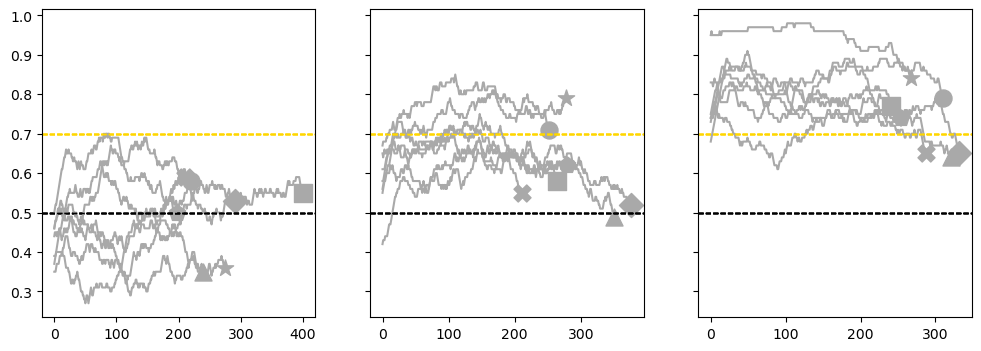

In [58]:
f,ax=plt.subplots(1,3,figsize=(12,4),sharey='row')
markers = ['o', 's', '^', 'D', 'X', '*', 'p']
for i in range(len(beh_arr_naive)):
    if i == 4:
        beh_arr_learning[i] = beh_arr_learning[i][:-50]
    ax[0].plot(beh_arr_naive[i], color='darkgrey', alpha=1)
    ax[1].plot(beh_arr_learning[i], color='darkgrey', alpha= 1)
    ax[2].plot(beh_arr_expert[i], color='darkgrey', alpha=1) 

    ax[0].scatter([len(beh_arr_naive[i])], [beh_arr_naive[i][-1]], color='darkgrey', s=150, marker=markers[i])
    ax[1].scatter([len(beh_arr_learning[i])], [beh_arr_learning[i][-1]], color='darkgrey', s=150, marker=markers[i])
    ax[2].scatter([len(beh_arr_expert[i])], [beh_arr_expert[i][-1]], color='darkgrey', s=150, marker=markers[i])

    for j in range(3):

        ax[j].axhline(0.5, color='black', linestyle='--', linewidth=1)
        ax[j].axhline(0.7, color='gold', linestyle='--', linewidth=1)
plt.savefig(r'P:\paperfigures\fig2\beh_acc_across_sessions_traces.pdf')

# ax[0].plot(np.mean(beh_arr_naive, axis=0), color='#9e9ac8')
# ax[1].plot(np.mean(beh_arr_learning, axis=0), color='#54278f')
# ax[2].plot(np.mean(beh_arr_expert, axis=0), color='#54278f')

In [45]:
[[beh_arr_learning[i][-1]] for i in range(len(beh_arr_learning))]

[[0.71], [0.49000000000000005], [0.52], [0.34], [0.79], [0.6200000000000001]]

Single Neuron examples: Sample Delay Action


Heatmap of selectivity

Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
0.8938157558441162
Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857
Minimum cutoff is 61
No water leak!
normalizing
-1.8049724
-1.8049724
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
0.8084805011749268
Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046
Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193
Minimum cutoff is 61
No water leak!
normalizing
1.1002567
1.1002567
3.1342051029205322
Minimum cutoff is 61
No water leak!
normalizing
5.565901
5.565901
Minimum cutoff is 61
No water leak!
normalizing
0.09465302
0.09465302
Minimum cutoff is 61
No water leak!
normalizing
1.7143317
1.7143317
0.7938170433044434
Minimum cutoff is 61
No water leak!
normalizing
-0.32274458
-0.32274458
Minimum cutoff is 61
No water leak!
normalizing
-2.061139
-2.061139
Minimum cutoff is 152
No water leak!
normalizing
-0.30559444
-0.30

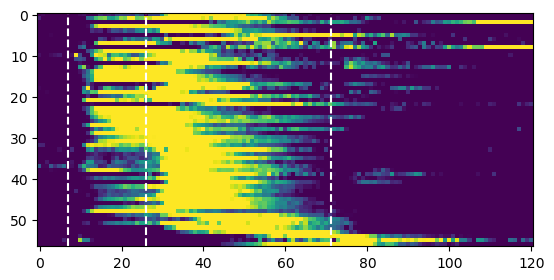

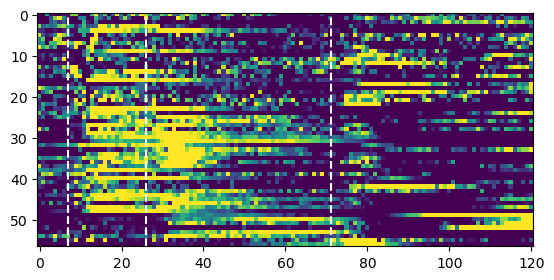

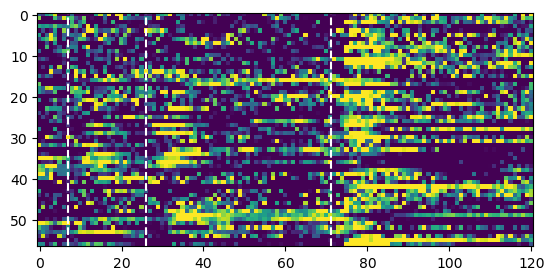

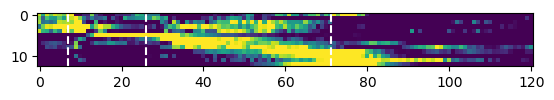

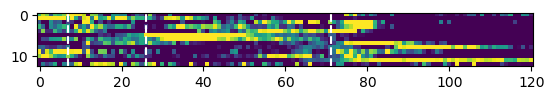

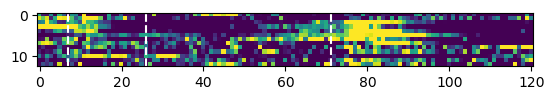

In [6]:
# Heatmap - Left and right preferring neurons over NLE (unmatched and matched)

def z_score_normalize(data):
    return (data - np.mean(data)) / np.std(data)
    
naivepath, learningpath, expertpath=[r'F:\data\BAYLORCW037\python\2023_11_21',
            r'F:\data\BAYLORCW037\python\2023_12_08',
            r'F:\data\BAYLORCW037\python\2023_12_15',]

all_L_traces = []
all_L_traces_naive = []
all_L_traces_learning = []


all_R_traces = []
all_R_traces_naive = []
all_R_traces_learning = []


for paths in all_matched_paths:

    naivepath, learningpath, expertpath = paths
    
    s1 = session.Session(expertpath, use_reg=True, triple=True)

    # Only delay neurons (don't use)
    # neurons, tstat = s1.get_epoch_selective(epoch = range(s1.delay-1, s1.response), p=0.01, return_stat=True)
    # neurons_excl_response, _ = s1.get_epoch_selective(epoch = range(s1.response, s1.time_cutoff), p=0.05, return_stat=True)
    # include_idx = [np.where(neurons == n)[0][0] for n in neurons if n not in neurons_excl_response]

    # all selective neurons
    neurons, tstat = s1.get_epoch_selective(epoch = range(s1.sample, s1.response+2), p=0.01, return_stat=True)
    include_idx = range(len(neurons))

    neurons = np.array(neurons)[include_idx]
    tstat = np.array(tstat)[include_idx]

    tstatidx = np.where(np.array(tstat) > 0)[0]
    l_neurons = np.array(neurons)[tstatidx]
    L_traces, _ = s1.get_trace_matrix_multiple(l_neurons, trialtype=True) 

    # add a normalizing step for every neuron
    L_traces = np.array([z_score_normalize(L_traces[i]) for i in range(L_traces.shape[0])])
    #
    L_traces_delay = L_traces[:, ] # range(s1.delay, s1.response)] # only consider delay
    max_timestep = [np.argmax(i) for i in L_traces_delay]
    neuron_idx = np.argsort(max_timestep)
    max_timestep_sorted = np.array(max_timestep)[neuron_idx]
    threshold_response = np.where(max_timestep_sorted > s1.response)[0][0] + 2
    l_neuron_idx = neuron_idx[:threshold_response]
    #
    sorted_neurons = l_neurons[l_neuron_idx]
    l_good_idx = [np.where(s1.good_neurons == n)[0][0] for n in sorted_neurons]

    _, L_traces = s1.get_trace_matrix_multiple(l_neurons, trialtype=True) # Diff trial type to show negative result
    # add a normalizing step for every neuron
    L_traces = np.array([z_score_normalize(L_traces[i]) for i in range(L_traces.shape[0])])

    # same for right pref neurons

    tstatidx = np.where(np.array(tstat) < 0)[0]
    r_neurons = np.array(neurons)[tstatidx]
    R_traces, _ = s1.get_trace_matrix_multiple(r_neurons, trialtype=True) 

    # add a normalizing step for every neuron
    R_traces = np.array([z_score_normalize(R_traces[i]) for i in range(R_traces.shape[0])])
    #
    R_traces_delay = R_traces[:, ] # range(s1.delay, s1.response)] # only consider delay
    max_timestep = [np.argmax(i) for i in R_traces_delay]
    neuron_idx = np.argsort(max_timestep)
    max_timestep_sorted = np.array(max_timestep)[neuron_idx]
    threshold_response = np.where(max_timestep_sorted > s1.response)[0][0] + 2
    r_neuron_idx = neuron_idx[:threshold_response]
    #
    sorted_neurons = r_neurons[r_neuron_idx]
    r_good_idx = [np.where(s1.good_neurons == n)[0][0] for n in sorted_neurons]

    R_traces, _ = s1.get_trace_matrix_multiple(r_neurons, trialtype=True) # Diff trial type to show negative result
    # add a normalizing step for every neuron
    R_traces = np.array([z_score_normalize(R_traces[i]) for i in range(R_traces.shape[0])])


    #%%
    s2 = session.Session(naivepath, use_reg=True, triple=True)

    neurons = s2.good_neurons[l_good_idx]
    L_traces_naive, _ = s2.get_trace_matrix_multiple(neurons)
    neurons = s2.good_neurons[r_good_idx]
    _, R_traces_naive = s2.get_trace_matrix_multiple(neurons)
    # _, L_traces_naive = s2.get_trace_matrix_multiple(neurons)

    L_traces_naive = np.array([z_score_normalize(L_traces_naive[i]) for i in range(L_traces_naive.shape[0])])
    R_traces_naive = np.array([z_score_normalize(R_traces_naive[i]) for i in range(R_traces_naive.shape[0])])

    s2 = session.Session(learningpath, use_reg=True, triple=True)

    neurons = s2.good_neurons[l_good_idx]
    L_traces_learning, _ = s2.get_trace_matrix_multiple(neurons)
    neurons = s2.good_neurons[r_good_idx]
    _, R_traces_learning = s2.get_trace_matrix_multiple(neurons)
    
    # _, L_traces_naive = s2.get_trace_matrix_multiple(neurons)

    L_traces_learning = np.array([z_score_normalize(L_traces_learning[i]) for i in range(L_traces_learning.shape[0])])
    R_traces_learning = np.array([z_score_normalize(R_traces_learning[i]) for i in range(R_traces_learning.shape[0])])

    all_L_traces.append(L_traces[l_neuron_idx, :])
    all_L_traces_naive.append(L_traces_naive)
    all_L_traces_learning.append(L_traces_learning)

    all_R_traces.append(R_traces[r_neuron_idx, :])
    all_R_traces_naive.append(R_traces_naive)
    all_R_traces_learning.append(R_traces_learning)

#%% Save to file
# savepath = r'H:\data\BAYLORCW046\python'
# scio.savemat(savepath+r'\expert_delay_othertt.mat', {'expert_stack': L_traces[neuron_idx, int(2*1/s1.fs):]})
# scio.savemat(savepath+r'\naive_delay_othertt.mat', {'naive_stack': L_traces_naive[:, int(2*1/s1.fs):]})



#%% plot left
plt.imshow(L_traces[l_neuron_idx, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()

plt.imshow(L_traces_learning[:, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()


plt.imshow(L_traces_naive[:, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()


#%% plot right
plt.imshow(R_traces[r_neuron_idx, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()

plt.imshow(R_traces_learning[:, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()


plt.imshow(R_traces_naive[:, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()




In [ ]:
# Resort all  neurons together
# 
# # Plot all as heatmap

plt.imshow(np.vstack(all_L_traces)[:, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()

plt.imshow(np.vstack(all_L_traces_learning)[:, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()

plt.imshow(np.vstack(all_L_traces_naive)[:, int(2*1/s1.fs):], cmap='viridis', vmin=-0.2, vmax=1.3)
plt.axvline(s1.sample - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.delay - int(2*1/s1.fs), ls = '--', color='white')
plt.axvline(s1.response - int(2*1/s1.fs), ls = '--', color='white')

plt.show()


In [5]:
# Heatmap grouped by selectivity (SDR buckets, use Sankey classification)

# Plot activity also try plotting selectivity (Chen at al 2021, Fig S1A)

# Heatmap - Left and right preferring neurons over NLE (unmatched and matched)

def z_score_normalize(data):
    return (data - np.mean(data)) / np.std(data)
    
p=0.001

all_L_traces_expert_sample = []
all_L_traces_naive_sample = []
all_L_traces_learning_sample = []

all_L_traces_expert_delay = []
all_L_traces_naive_delay = []
all_L_traces_learning_delay = []

all_L_traces_expert_response = []
all_L_traces_naive_response = []
all_L_traces_learning_response = []

all_R_traces_expert_sample = []
all_R_traces_naive_sample = []
all_R_traces_learning_sample = []

all_R_traces_expert_delay = []
all_R_traces_naive_delay = []
all_R_traces_learning_delay = []    

all_R_traces_expert_response = []
all_R_traces_naive_response = []
all_R_traces_learning_response = []

all_sel_traces_expert_response = []
all_sel_traces_expert_delay = []
all_sel_traces_expert_sample = []

all_sel_traces_naive_response = []
all_sel_traces_naive_delay = []
all_sel_traces_naive_sample = [] 

all_sel_traces_learning_response = []
all_sel_traces_learning_delay = []
all_sel_traces_learning_sample = []


for paths in all_matched_paths:

    naivepath, learningpath, expertpath = paths
    
    s1 = session.Session(expertpath, use_reg=True, triple=True)
    s2 = session.Session(learningpath, use_reg=True, triple=True)
    s3 = session.Session(naivepath, use_reg=True, triple=True)

    sample_epoch = range(s1.sample, s1.delay)
    delay_epoch = range(s1.delay+int(1.5 * 1/s1.fs), s1.response)
    response_epoch = range(s1.response, s1.response + int(2*1/s1.fs))

    expert_sample_sel, tstat_sample = s1.get_epoch_selective(sample_epoch, p=p, return_stat=True)
    
    expert_delay_sel, tstat_delay = s1.get_epoch_selective(delay_epoch, p=p, return_stat=True)
    tstat_delay = [tstat_delay[n] for n in range(len(tstat_delay)) if expert_delay_sel[n] not in expert_sample_sel]
    expert_delay_sel = [n for n in expert_delay_sel if n not in expert_sample_sel]

    expert_response_sel, tstat_response = s1.get_epoch_selective(response_epoch, p=p, return_stat=True)
    tstat_response = [tstat_response[n] for n in range(len(tstat_response)) if expert_response_sel[n] not in expert_sample_sel and expert_response_sel[n] not in expert_delay_sel]
    expert_response_sel = [n for n in expert_response_sel if n not in expert_sample_sel and n not in expert_delay_sel]

    expert_nonsel = [n for n in s1.good_neurons if n not in expert_sample_sel and n not in expert_delay_sel and n not in expert_response_sel]


    # Left preferring

    ### Sample ###
    tstatidx = np.where(np.array(tstat_sample) > 0)[0]
    l_neurons = np.array(expert_sample_sel)[tstatidx]
    L_traces, R_traces = s1.get_trace_matrix_multiple(l_neurons, trialtype=False) 
    # add a normalizing step for every neuron
    # L_traces_sample = np.array([z_score_normalize(L_traces[i]) for i in range(L_traces.shape[0])])

    l_good_idx = [np.where(s1.good_neurons == n)[0][0] for n in l_neurons]
    neurons = s3.good_neurons[l_good_idx]
    L_traces_naive, R_traces_naive = s3.get_trace_matrix_multiple(neurons)
    # L_traces_naive = np.array([z_score_normalize(L_traces_naive[i]) for i in range(L_traces_naive.shape[0])])
    neurons = s2.good_neurons[l_good_idx]
    L_traces_learning, R_traces_learning = s2.get_trace_matrix_multiple(neurons)
    # L_traces_learning = np.array([z_score_normalize(L_traces_learning[i]) for i in range(L_traces_learning.shape[0])])

    all_L_traces_naive_sample.append(L_traces_naive)
    all_L_traces_learning_sample.append(L_traces_learning)

    all_sel_traces_expert_sample.append(L_traces - R_traces)
    all_sel_traces_naive_sample.append(L_traces_naive - R_traces_naive)
    all_sel_traces_learning_sample.append(L_traces_learning - R_traces_learning)

    # same for right pref neurons
    tstatidx = np.where(np.array(tstat_sample) < 0)[0]
    r_neurons = np.array(expert_sample_sel)[tstatidx]
    L_traces, R_traces = s1.get_trace_matrix_multiple(r_neurons, trialtype=True) 
    # add a normalizing step for every neuron
    # R_traces_sample = np.array([z_score_normalize(R_traces[i]) for i in range(R_traces.shape[0])])

    # learning and naive
    r_good_idx = [np.where(s1.good_neurons == n)[0][0] for n in r_neurons]
    neurons = s3.good_neurons[r_good_idx]
    L_traces_naive, R_traces_naive = s3.get_trace_matrix_multiple(neurons)
    # R_traces_naive = np.array([z_score_normalize(R_traces_naive[i]) for i in range(R_traces_naive.shape[0])])
    neurons = s2.good_neurons[r_good_idx]
    L_traces_learning, R_traces_learning = s2.get_trace_matrix_multiple(neurons)
    # R_traces_learning = np.array([z_score_normalize(R_traces_learning[i]) for i in range(R_traces_learning.shape[0])])

    all_R_traces_naive_sample.append(R_traces_naive)
    all_R_traces_learning_sample.append(R_traces_learning)

    all_sel_traces_expert_sample.append(R_traces - L_traces)
    all_sel_traces_naive_sample.append(R_traces_naive - L_traces_naive)
    all_sel_traces_learning_sample.append(R_traces_learning - L_traces_learning)

    ### Delay ###
    tstatidx = np.where(np.array(tstat_delay) > 0)[0]
    l_neurons = np.array(expert_delay_sel)[tstatidx]
    L_traces, R_traces = s1.get_trace_matrix_multiple(l_neurons, trialtype=True) 
    # add a normalizing step for every neuron
    # L_traces_delay = np.array([z_score_normalize(L_traces[i]) for i in range(L_traces.shape[0])])

    l_good_idx = [np.where(s1.good_neurons == n)[0][0] for n in l_neurons]
    neurons = s3.good_neurons[l_good_idx]
    L_traces_naive,R_traces_naive = s3.get_trace_matrix_multiple(neurons)
    # L_traces_naive = np.array([z_score_normalize(L_traces_naive[i]) for i in range(L_traces_naive.shape[0])])
    neurons = s2.good_neurons[l_good_idx]
    L_traces_learning,R_traces_learning = s2.get_trace_matrix_multiple(neurons)
    # L_traces_learning = np.array([z_score_normalize(L_traces_learning[i]) for i in range(L_traces_learning.shape[0])])

    all_L_traces_naive_delay.append(L_traces_naive)
    all_L_traces_learning_delay.append(L_traces_learning)

    all_sel_traces_expert_delay.append(L_traces - R_traces)
    all_sel_traces_naive_delay.append(L_traces_naive - R_traces_naive)
    all_sel_traces_learning_delay.append(L_traces_learning - R_traces_learning)

    # same for right pref neurons
    tstatidx = np.where(np.array(tstat_delay) < 0)[0]
    r_neurons = np.array(expert_delay_sel)[tstatidx]
    L_traces, R_traces = s1.get_trace_matrix_multiple(r_neurons, trialtype=True) 
    # add a normalizing step for every neuron
    # R_traces_delay = np.array([z_score_normalize(R_traces[i]) for i in range(R_traces.shape[0])])

    r_good_idx = [np.where(s1.good_neurons == n)[0][0] for n in r_neurons]
    neurons = s3.good_neurons[r_good_idx]
    L_traces_naive, R_traces_naive = s3.get_trace_matrix_multiple(neurons)
    # R_traces_naive = np.array([z_score_normalize(R_traces_naive[i]) for i in range(R_traces_naive.shape[0])])
    neurons = s2.good_neurons[r_good_idx]
    L_traces_learning, R_traces_learning = s2.get_trace_matrix_multiple(neurons)
    # R_traces_learning = np.array([z_score_normalize(R_traces_learning[i]) for i in range(R_traces_learning.shape[0])])

    all_R_traces_naive_delay.append(R_traces_naive)
    all_R_traces_learning_delay.append(R_traces_learning)

    all_sel_traces_expert_delay.append(R_traces - L_traces)
    all_sel_traces_naive_delay.append(R_traces_naive - L_traces_naive)
    all_sel_traces_learning_delay.append(R_traces_learning - L_traces_learning)


    ### Response ###
    tstatidx = np.where(np.array(tstat_response) > 0)[0]
    l_neurons = np.array(expert_response_sel)[tstatidx]
    L_traces, R_traces = s1.get_trace_matrix_multiple(l_neurons, trialtype=True) 
    # add a normalizing step for every neuron
    # L_traces_response = np.array([z_score_normalize(L_traces[i]) for i in range(L_traces.shape[0])])

    l_good_idx = [np.where(s1.good_neurons == n)[0][0] for n in l_neurons]
    neurons = s3.good_neurons[l_good_idx]
    L_traces_naive, R_traces_naive = s3.get_trace_matrix_multiple(neurons)
    # L_traces_naive = np.array([z_score_normalize(L_traces_naive[i]) for i in range(L_traces_naive.shape[0])])
    neurons = s2.good_neurons[l_good_idx]
    L_traces_learning, R_traces_learning = s2.get_trace_matrix_multiple(neurons)
    # L_traces_learning = np.array([z_score_normalize(L_traces_learning[i]) for i in range(L_traces_learning.shape[0])])

    all_L_traces_naive_response.append(L_traces_naive)
    all_L_traces_learning_response.append(L_traces_learning)

    all_sel_traces_expert_response.append(L_traces - R_traces)
    all_sel_traces_naive_response.append(L_traces_naive - R_traces_naive)
    all_sel_traces_learning_response.append(L_traces_learning - R_traces_learning)


    # same for right pref neurons
    tstatidx = np.where(np.array(tstat_response) < 0)[0]
    r_neurons = np.array(expert_response_sel)[tstatidx]
    L_traces, R_traces = s1.get_trace_matrix_multiple(r_neurons, trialtype=True) 
    # add a normalizing step for every neuron
    # R_traces_response = np.array([z_score_normalize(R_traces[i]) for i in range(R_traces.shape[0])])

    r_good_idx = [np.where(s1.good_neurons == n)[0][0] for n in r_neurons]
    neurons = s3.good_neurons[r_good_idx]
    L_traces_naive, R_traces_naive = s3.get_trace_matrix_multiple(neurons)
    # R_traces_naive = np.array([z_score_normalize(R_traces_naive[i]) for i in range(R_traces_naive.shape[0])])
    neurons = s2.good_neurons[r_good_idx]
    L_traces_learning, R_traces_learning = s2.get_trace_matrix_multiple(neurons)
    # R_traces_learning = np.array([z_score_normalize(R_traces_learning[i]) for i in range(R_traces_learning.shape[0])])

    all_R_traces_naive_response.append(R_traces_naive)
    all_R_traces_learning_response.append(R_traces_learning)

    all_sel_traces_expert_response.append(R_traces - L_traces)
    all_sel_traces_naive_response.append(R_traces_naive - L_traces_naive)
    all_sel_traces_learning_response.append(R_traces_learning - L_traces_learning)


    # append neurons to list
    # all_L_traces_expert_sample.append(L_traces_sample)
    # all_L_traces_expert_delay.append(L_traces_delay)
    # all_L_traces_expert_response.append(L_traces_response)

    # all_R_traces_expert_sample.append(R_traces_sample)
    # all_R_traces_expert_delay.append(R_traces_delay)
    # all_R_traces_expert_response.append(R_traces_response)

   






Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
Minimum cutoff is 61
No water leak!
normalizing
-1.8049724
-1.8049724
Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857
1.1042723655700684
1.1157970428466797
1.037837266921997
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
Minimum cutoff is 61
No water leak!
normalizing
-4.525193
-4.525193
Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046
0.8613941669464111
0.9049072265625
0.8865208625793457
Minimum cutoff is 61
No water leak!
normalizing
1.1002567
1.1002567
Minimum cutoff is 61
No water leak!
normalizing
0.09465302
0.09465302
Minimum cutoff is 61
No water leak!
normalizing
5.565901
5.565901
3.990243673324585
4.0345964431762695
4.068547487258911
Minimum cutoff is 61
No water leak!
normalizing
1.7143317
1.7143317
Minimum cutoff is 61
No water leak!
normalizing
-2.061139
-2.061139
Minimum cutoff is 61
No water leak!
normalizing
-

In [6]:
all_sel_traces_learning_response_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_learning_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_sel_traces_learning_delay_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_learning_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_sel_traces_learning_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_learning_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])


all_sel_traces_naive_response_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_naive_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_sel_traces_naive_delay_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_naive_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_sel_traces_naive_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_naive_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])  

all_sel_traces_expert_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_expert_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_sel_traces_expert_delay_mod = np.vstack([       
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_expert_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_sel_traces_expert_response_mod = np.vstack([    
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_sel_traces_expert_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_sel_traces_expert_response_mod.shape


    



(816, 61)

In [ ]:
all_R_traces_expert_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_expert_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_expert_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_expert_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_R_traces_expert_delay_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_expert_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_expert_delay_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_expert_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_R_traces_expert_response_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_expert_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_expert_response_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_expert_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_R_traces_naive_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_naive_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_naive_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_naive_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_R_traces_naive_delay_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_naive_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_naive_delay_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_naive_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_R_traces_naive_response_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_naive_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_naive_response_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_naive_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

all_R_traces_learning_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_learning_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_learning_sample_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_learning_sample
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_R_traces_learning_delay_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_learning_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_learning_delay_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_learning_delay
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_R_traces_learning_response_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_R_traces_learning_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])
all_L_traces_learning_response_mod = np.vstack([
    dodownsample(item) if hasattr(item, 'shape') and item.shape[1] > 61 else item
    for item in all_L_traces_learning_response
    if isinstance(item, (list, np.ndarray)) and len(item) > 0
])

In [9]:
# all_L_traces_learning_response_mod.shape, 
expert_r_pref_display.shape

(1202, 61)

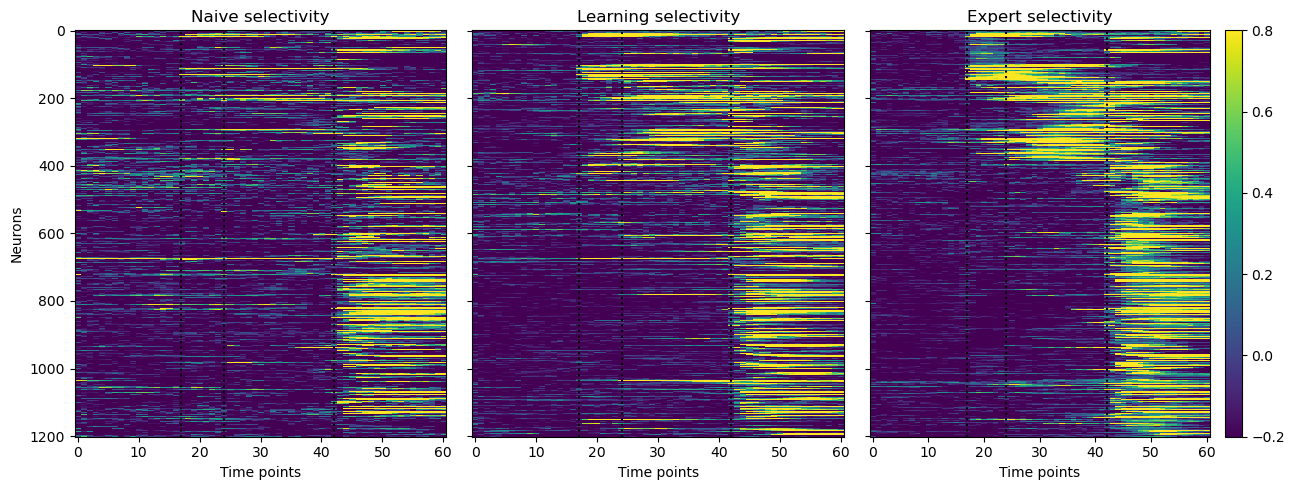

In [7]:
expert_r_pref = -(np.vstack([all_sel_traces_expert_sample_mod, all_sel_traces_expert_delay_mod, all_sel_traces_expert_response_mod]))
learning_r_pref = -(np.vstack([all_sel_traces_learning_sample_mod, all_sel_traces_learning_delay_mod, all_sel_traces_learning_response_mod]))
naive_r_pref = -(np.vstack([all_sel_traces_naive_sample_mod, all_sel_traces_naive_delay_mod, all_sel_traces_naive_response_mod]))

# Normalize all traces to have the same range
# Z-score normalize all three matrices together as a single population
all_pref_concat = np.vstack([expert_r_pref, learning_r_pref, naive_r_pref])
all_pref_concat_z = z_score_normalize(all_pref_concat)

# Split back into original matrices according to their row counts
ex_rows = expert_r_pref.shape[0]
le_rows = learning_r_pref.shape[0]
na_rows = naive_r_pref.shape[0]

expert_r_pref = all_pref_concat_z[:ex_rows]
learning_r_pref = all_pref_concat_z[ex_rows:ex_rows + le_rows]
naive_r_pref = all_pref_concat_z[ex_rows + le_rows:]



# Plot expert_l_pref as a heatmap with all rows shown and aspect ratio optimized for "squareness"
num_rows, num_cols = expert_r_pref.shape
col_start = int(2 * 1 / 6)
expert_r_pref_display = expert_r_pref[:, col_start:]

# Make the plot much more "compressed" vertically, stretched in x,
# resembling a ~5x6 rectangle (wider than it is tall)
fig_width, fig_height = 15, 5  # make the final figure ~15x5 inches (3 panels)
fig, axs = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True)

# Prepare display matrices for all three conditions
naive_r_pref_display = naive_r_pref[:, col_start:]
learning_r_pref_display = learning_r_pref[:, col_start:]
expert_r_pref_display = expert_r_pref[:, col_start:]

# vmin/vmax and aspect settings for all three to match
vmin, vmax = -0.2, 0.8
cmap = 'viridis'  # Red is now the largest value, thanks to _r (reversed) version of 'RdYlBu'
aspect = 'auto'

# Plot Naive
im0 = axs[0].imshow(
    naive_r_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[0].set_title("Naive selectivity")
axs[0].set_xlabel("Time points")
axs[0].set_ylabel("Neurons")

# Plot Learning
im1 = axs[1].imshow(
    learning_r_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[1].set_title("Learning selectivity")
axs[1].set_xlabel("Time points")
axs[1].set_ylabel("")  # Remove duplicated ylabel

# Plot Expert
im2 = axs[2].imshow(
    expert_r_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[2].set_title("Expert selectivity")
axs[2].set_xlabel("Time points")
axs[2].set_ylabel("")  # Remove duplicated ylabel

# Draw thick vertical black dotted lines at s1.sample, s1.delay, s1.response locations
event_times = [15, 22, 40]
for ax in axs:
    for t in event_times:
        # Calculate the corresponding column, adjusting for col_start
        # col = int(t * s1.fs) - col_start
        ax.axvline(t-col_start+2, color='k', linestyle=':', linewidth=1.5, alpha=1.0)

# Move colorbar to the far right of all subplots and match range,
# using a separate axes object outside the axs grid
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Get the parent of the last axs (rightmost), and create a divider for the entire figure
divider = make_axes_locatable(axs[-1])
cax = divider.append_axes("right", size="5%", pad=0.15)
plt.subplots_adjust(right=0.88)  # to make sure the colorbar fits at the side

cbar = fig.colorbar(im2, cax=cax, orientation='vertical')
plt.tight_layout(rect=[0, 0, 0.87, 1])  # leave room for side colorbar
plt.savefig(r'P:\paperfigures\NLEheatmap.pdf')
plt.show()



#### Plot raw activity traces

In [4]:
expert_r_pref = z_score_normalize(np.vstack([all_R_traces_expert_sample_mod, all_R_traces_expert_delay_mod, all_R_traces_expert_response_mod]))
learning_r_pref = z_score_normalize(np.vstack([all_R_traces_learning_sample_mod, all_R_traces_learning_delay_mod, all_R_traces_learning_response_mod]))
naive_r_pref = z_score_normalize(np.vstack([all_R_traces_naive_sample_mod, all_R_traces_naive_delay_mod, all_R_traces_naive_response_mod]))
# Stack all L traces, not R traces

# Plot expert_l_pref as a heatmap with all rows shown and aspect ratio optimized for "squareness"
num_rows, num_cols = expert_r_pref.shape
col_start = int(2 * 1 / 6)
expert_r_pref_display = expert_r_pref[:, col_start:]

# Make the plot much more "compressed" vertically, stretched in x,
# resembling a ~5x6 rectangle (wider than it is tall)
fig_width, fig_height = 15, 5  # make the final figure ~15x5 inches (3 panels)
fig, axs = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True)

# Prepare display matrices for all three conditions
naive_r_pref_display = naive_r_pref[:, col_start:]
learning_r_pref_display = learning_r_pref[:, col_start:]
expert_r_pref_display = expert_r_pref[:, col_start:]

# vmin/vmax and aspect settings for all three to match
vmin, vmax = -1, 1
cmap = 'RdBu'  # Red is now the largest value, thanks to _r (reversed) version of 'RdYlBu'
aspect = 'auto'

# Plot Naive
im0 = axs[0].imshow(
    naive_r_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[0].set_title("Naive R-pref Heatmap")
axs[0].set_xlabel("Time points")
axs[0].set_ylabel("Neurons")

# Plot Learning
im1 = axs[1].imshow(
    learning_r_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[1].set_title("Learning R-pref Heatmap")
axs[1].set_xlabel("Time points")
axs[1].set_ylabel("")  # Remove duplicated ylabel

# Plot Expert
im2 = axs[2].imshow(
    expert_r_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[2].set_title("Expert R-pref Heatmap")
axs[2].set_xlabel("Time points")
axs[2].set_ylabel("")  # Remove duplicated ylabel

# Draw thick vertical black dotted lines at s1.sample, s1.delay, s1.response locations
event_times = [15, 22, 40]
for ax in axs:
    for t in event_times:
        # Calculate the corresponding column, adjusting for col_start
        # col = int(t * s1.fs) - col_start
        ax.axvline(t-col_start+1, color='k', linestyle=':', linewidth=3, alpha=1.0)

# Move colorbar to the far right of all subplots and match range,
# using a separate axes object outside the axs grid
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Get the parent of the last axs (rightmost), and create a divider for the entire figure
divider = make_axes_locatable(axs[-1])
cax = divider.append_axes("right", size="5%", pad=0.15)
plt.subplots_adjust(right=0.88)  # to make sure the colorbar fits at the side

cbar = fig.colorbar(im2, cax=cax, orientation='vertical')
plt.tight_layout(rect=[0, 0, 0.87, 1])  # leave room for side colorbar
plt.show()



NameError: name 'all_R_traces_expert_sample_mod' is not defined

In [ ]:
# Stack all L traces, not R traces
expert_l_pref = z_score_normalize(np.vstack([all_L_traces_expert_sample_mod, all_L_traces_expert_delay_mod, all_L_traces_expert_response_mod]))
learning_l_pref = z_score_normalize(np.vstack([all_L_traces_learning_sample_mod, all_L_traces_learning_delay_mod, all_L_traces_learning_response_mod]))
naive_l_pref = z_score_normalize(np.vstack([all_L_traces_naive_sample_mod, all_L_traces_naive_delay_mod, all_L_traces_naive_response_mod]))

# Plot expert_l_pref as a heatmap with all rows shown and aspect ratio optimized for "squareness"
num_rows, num_cols = expert_l_pref.shape
col_start = int(2 * 1 / 6)
expert_l_pref_display = expert_l_pref[:, col_start:]

# Make the plot much more "compressed" vertically, stretched in x,
# resembling a ~5x6 rectangle (wider than it is tall)
fig_width, fig_height = 15, 5  # make the final figure ~15x5 inches (3 panels)
fig, axs = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True)

# Prepare display matrices for all three conditions
naive_l_pref_display = naive_l_pref[:, col_start:]
learning_l_pref_display = learning_l_pref[:, col_start:]
expert_l_pref_display = expert_l_pref[:, col_start:]

# vmin/vmax and aspect settings for all three to match
vmin, vmax = -0.75, 0.75
cmap = 'RdBu_r'  # Red is now the largest value, thanks to _r (reversed) version of 'RdYlBu'
aspect = 'auto'

# Plot Naive
im0 = axs[0].imshow(
    naive_l_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[0].set_title("Naive L-pref Heatmap")
axs[0].set_xlabel("Time points")
axs[0].set_ylabel("Neurons")

# Plot Learning
im1 = axs[1].imshow(
    learning_l_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[1].set_title("Learning L-pref Heatmap")
axs[1].set_xlabel("Time points")
axs[1].set_ylabel("")  # Remove duplicated ylabel

# Plot Expert
im2 = axs[2].imshow(
    expert_l_pref_display,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    aspect=aspect,
    interpolation='nearest'
)
axs[2].set_title("Expert L-pref Heatmap")
axs[2].set_xlabel("Time points")
axs[2].set_ylabel("")  # Remove duplicated ylabel

# Draw thick vertical black dotted lines at s1.sample, s1.delay, s1.response locations
event_times = [15, 22, 40]
for ax in axs:
    for t in event_times:
        # Calculate the corresponding column, adjusting for col_start
        # col = int(t * s1.fs) - col_start
        ax.axvline(t-col_start+1, color='k', linestyle=':', linewidth=3, alpha=1.0)

# Move colorbar to the far right of all subplots and match range,
# using a separate axes object outside the axs grid
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Get the parent of the last axs (rightmost), and create a divider for the entire figure
divider = make_axes_locatable(axs[-1])
cax = divider.append_axes("right", size="5%", pad=0.15)
plt.subplots_adjust(right=0.88)  # to make sure the colorbar fits at the side

cbar = fig.colorbar(im2, cax=cax, orientation='vertical')
plt.tight_layout(rect=[0, 0, 0.87, 1])  # leave room for side colorbar
plt.show()


## Sankey diagram

In [64]:
all_matched_paths = [
    
            [r'F:\data\BAYLORCW032\python\2023_10_05',
              r'F:\data\BAYLORCW032\python\2023_10_19',
              r'F:\data\BAYLORCW032\python\2023_10_24',
          ],
         
           # [ r'F:\data\BAYLORCW034\python\2023_10_12',
           #    r'F:\data\BAYLORCW034\python\2023_10_22',
           #    r'F:\data\BAYLORCW034\python\2023_10_27',
           #    r'F:\data\BAYLORCW034\python\cellreg\layer{}\1012_1022_1027pairs_proc.npy'],
         
            [r'F:\data\BAYLORCW036\python\2023_10_09',
            r'F:\data\BAYLORCW036\python\2023_10_19',
            r'F:\data\BAYLORCW036\python\2023_10_30',
           ],
         
         [r'F:\data\BAYLORCW037\python\2023_11_21',
            r'F:\data\BAYLORCW037\python\2023_12_08',
            r'F:\data\BAYLORCW037\python\2023_12_15',],
         
         [r'F:\data\BAYLORCW035\python\2023_10_26',
            r'F:\data\BAYLORCW035\python\2023_12_07',
            r'F:\data\BAYLORCW035\python\2023_12_15',],
         
         [r'H:\data\BAYLORCW044\python\2024_05_22',
          r'H:\data\BAYLORCW044\python\2024_06_06',
        r'H:\data\BAYLORCW044\python\2024_06_19'],

         
            [r'H:\data\BAYLORCW044\python\2024_05_23',
             r'H:\data\BAYLORCW044\python\2024_06_04',
        r'H:\data\BAYLORCW044\python\2024_06_18'],

            [r'H:\data\BAYLORCW046\python\2024_05_29',
             r'H:\data\BAYLORCW046\python\2024_06_24',
             r'H:\data\BAYLORCW046\python\2024_06_28'],


            [r'H:\data\BAYLORCW046\python\2024_05_30',
             r'H:\data\BAYLORCW046\python\2024_06_10',
             r'H:\data\BAYLORCW046\python\2024_06_27'],

            [r'H:\data\BAYLORCW046\python\2024_05_31',
             r'H:\data\BAYLORCW046\python\2024_06_11',
             r'H:\data\BAYLORCW046\python\2024_06_26'
             ]
         
        ]


In [65]:
p=0.001
retained_sample = []
recruited_sample = []
retained_delay = []
recruited_delay = []
dropped_delay = []
dropped_sample = []
alls1list, alld1, allr1, allns1 = [],[],[],[]
for paths in all_matched_paths: # For each mouse/FOV
    ret_s = []
    recr_s = []
    ret_d, recr_d = [],[]
    drop_d, drop_s = [], []
    
    s1list, d1, r1, ns1 = np.zeros(4),np.zeros(4),np.zeros(4),np.zeros(4)

    s1 = session.Session(paths[0], use_reg=True, triple=True, use_background_sub=False) # Naive

    sample_epoch = range(s1.sample, s1.delay)
    delay_epoch = range(s1.delay+int(1.5 * 1/s1.fs), s1.response)
    response_epoch = range(s1.response, s1.response + int(2*1/s1.fs))
    
    naive_sample_sel = s1.get_epoch_selective(sample_epoch, p=p)
    
    naive_delay_sel = s1.get_epoch_selective(delay_epoch, p=p)
    naive_delay_sel = [n for n in naive_delay_sel if n not in naive_sample_sel]
    
    naive_response_sel = s1.get_epoch_selective(response_epoch, p=p)
    naive_response_sel = [n for n in naive_response_sel if n not in naive_sample_sel and n not in naive_delay_sel]

    naive_nonsel = [n for n in s1.good_neurons if n not in naive_sample_sel and n not in naive_delay_sel and n not in naive_response_sel]

    s2 = session.Session(paths[2], use_reg=True, triple=True) # Learning or expert
    
    for n in naive_sample_sel:
        if s2.is_selective(s2.good_neurons[np.where(s1.good_neurons == n)[0][0]], sample_epoch, p=p):
            s1list[0] += 1
            ret_s += [(n, s2.good_neurons[np.where(s1.good_neurons == n)[0][0]])]
        elif s2.is_selective(s2.good_neurons[np.where(s1.good_neurons == n)[0][0]], delay_epoch, p=p):
            s1list[1] += 1
        elif s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], response_epoch, p=p):
            s1list[2] += 1
        else:
            s1list[3] += 1
            drop_s += [(n, s2.good_neurons[np.where(s1.good_neurons == n)[0][0]])]

    for n in naive_delay_sel:
        if s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], sample_epoch, p=p):
            d1[0] += 1
        elif s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], delay_epoch, p=p):
            d1[1] += 1
            ret_d += [(n, s2.good_neurons[np.where(s1.good_neurons == n)[0][0]])]

        elif s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], response_epoch, p=p):
            d1[2] += 1
        else:
            d1[3] += 1
            drop_d += [(n, s2.good_neurons[np.where(s1.good_neurons == n)[0][0]])]
    
    
    for n in naive_response_sel:
        if s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], sample_epoch, p=p):
            r1[0] += 1

        elif s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], delay_epoch, p=p):
            r1[1] += 1

        elif s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], response_epoch, p=p):
            r1[2] += 1
        else:
            r1[3] += 1
    
    
    for n in naive_nonsel:
        if s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], sample_epoch, p=p):
            ns1[0] += 1
            recr_s += [(n, s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]])]
        elif s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], delay_epoch, p=p):
            ns1[1] += 1
            recr_d += [(n, s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]])]

        elif s2.is_selective(s2.good_neurons[np.where(s1.good_neurons ==n)[0][0]], response_epoch, p=p):
            ns1[2] += 1
        else:
            ns1[3] += 1

    s1list, d1, r1, ns1 = s1list / len(s1.good_neurons), d1 / len(s1.good_neurons), r1 / len(s1.good_neurons), ns1 / len(s1.good_neurons)
    
    alls1list += [s1list]
    alld1 += [d1]
    allr1 += [r1] 
    allns1 += [ns1]
    
    retained_sample += [ret_s]
    recruited_sample += [recr_s]
    dropped_sample += [drop_s]
    retained_delay += [ret_d]
    recruited_delay += [recr_d]
    dropped_delay += [drop_d]

# alls1list = np.mean(alls1list, axis=0) 
# alld1 = np.mean(alld1, axis=0)
# allr1 = np.mean(allr1, axis=0)
# allns1 = np.mean(allns1, axis=0)

Minimum cutoff is 61
More Bpod trials than 2 photon trials
No water leak!
normalizing
-1.4970857
-1.4970857
1.2431070804595947
1.2396612167358398
1.2202224731445312
Minimum cutoff is 61
No water leak!
normalizing
7.06431
7.06431
Minimum cutoff is 61
No water leak!
normalizing
7.6270046
7.6270046
0.5840699672698975
0.5852625370025635
0.5992021560668945
Minimum cutoff is 61
No water leak!
normalizing
-4.008582
-4.008582
Minimum cutoff is 61
No water leak!
normalizing
5.565901
5.565901
2.8107011318206787
2.880241632461548
2.928619146347046
Minimum cutoff is 61
No water leak!
normalizing
1.1002567
1.1002567
Minimum cutoff is 61
No water leak!
normalizing
-0.32274458
-0.32274458
0.778275728225708
0.8553595542907715
0.8411962985992432
Minimum cutoff is 61
No water leak!
normalizing
1.7143317
1.7143317
Minimum cutoff is 151
No water leak!
normalizing
-0.12740667
-0.12740667
1.561025619506836
1.5387821197509766
1.6615545749664307
Minimum cutoff is 152
No water leak!
normalizing
-0.30559444
-0.

In [69]:
alls1list = np.mean(alls1list, axis=0) 
alld1 = np.mean(alld1, axis=0)
allr1 = np.mean(allr1, axis=0)
allns1 = np.mean(allns1, axis=0)

In [73]:

#%% Calculate SDR signifiances
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare

# allnums = np.vstack((s1list, d1, r1, ns1))
allnums = np.vstack((alls1list, alld1, allr1, allns1)) * 3028
exptotals = np.sum(allnums, axis=0)
# Calculate significance using binomial/proportion z-test

for i in range(4): # SDR
    print("####################")
    for j in range(4): #Where the bucket went
        # Input data
        count = allnums[i, j]   # number of successes
        nobs = np.sum(allnums[i])    # total number of observations
        value = exptotals[j] / np.sum(exptotals) # hypothesized proportion
        
        # Perform one-proportion z-test
        z_stat, p_value = proportions_ztest(count, nobs, value, alternative='larger')
        
        # Output the results
        print(f"Z-statistic: {z_stat}")
        print(f"P-value: {p_value}")



####################
Z-statistic: 5.171153106997386
P-value: 1.1632692061235708e-07
Z-statistic: 0.00371069577684534
P-value: 0.49851964996213166
Z-statistic: -2.1763799227399776
P-value: 0.985236568103132
Z-statistic: -4.579445545564475
P-value: 0.9999976689492859
####################
Z-statistic: 1.05404985779591
P-value: 0.14593004557826206
Z-statistic: 2.0100536478111306
P-value: 0.02221275558176118
Z-statistic: -0.31567307074238987
P-value: 0.6238746656360853
Z-statistic: -2.1699009905289666
P-value: 0.9849928263565895
####################
Z-statistic: 2.2584956272245233
P-value: 0.011957388444268725
Z-statistic: 0.425710646293883
P-value: 0.3351593517076349
Z-statistic: 9.30635483919226
P-value: 6.614738197238713e-21
Z-statistic: -11.281816315184736
P-value: 1.0
####################
Z-statistic: -2.601988975098945
P-value: 0.9953657584114901
Z-statistic: -0.5009670608138463
P-value: 0.6918028475022016
Z-statistic: -4.2642122782831215
P-value: 0.9999899695670865
Z-statistic: 5.036

In [74]:

#%% Use Chi-square for overall comparison of proportions (no greater/less than expected info)
# Forward probabilities
for i in range(4):
    res = chisquare(f_obs=allnums[i], f_exp=exptotals / sum(exptotals) * sum(allnums[i]))
    print(res.pvalue)

allnums = allnums.T
exptotals = np.sum(allnums, axis=0)
# Backwards probabilities
for i in range(4):
    res = chisquare(f_obs=allnums[i], f_exp=exptotals / sum(exptotals) * sum(allnums[i]))
    print(res.pvalue)

    

3.949970601690205e-30
0.004896624909994358
4.870455661825613e-31
6.5213949675955345e-06
8.792800153114151e-32
0.027749711340373358
2.109304345482829e-22
1.3541298851233872e-13
